In [154]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.linalg import lu_factor, lu_solve
import scipy
import time
from scipy.interpolate import lagrange
import matplotlib.colors as mcolors

from ader_dg_transport.ader_dg_2D.base_ader_dg_2D import BaseADERDG2D
from ader_dg_transport.ader_dg_2D.wave_ader_standard import WaveStandardAderDG2D
from ader_dg_transport.ader_dg_2D.wave_ader import WaveAderDG2D
import matplotlib.ticker as mticker

In [2]:
xlim = 10.0
nx = 20
poly_order = 10 # 0.9, 0.6, 0.38
cfl = 0.1
solver = BaseADERDG2D(xlim, xlim, nx, nx, poly_order)

xs = solver.xs[:, :, 0]
ys = solver.ys[:, :, 0]
h0 = np.exp(-(xs - 5)**2 -(ys - 5)**2)

n = 15
lk_coeffs = {}

l_vals = []
k_vals = []
coeffs = []

for l in range(-n, n):
    k_coeffs = {}
    for k in range(-n, n):
        basis_function = np.exp(-1.0j * (l * xs + k * ys) * 2 * np.pi / solver.xlim)
        coeff = solver.integrate(basis_function * h0) / solver.xlim**2
    
        k_coeffs[k] = coeff

        l_vals.append(l)
        k_vals.append(k)
        coeffs.append(coeff)
    
    lk_coeffs[l] = k_coeffs

l_vals = np.array(l_vals)
k_vals = np.array(k_vals)
coeffs = np.array(coeffs)

In [3]:
def analytic_solution(solver, t=None):
    if t is None:
        t = solver.time
    w1 = np.sqrt(k_vals**2 + l_vals**2)
    w2 = -np.sqrt(k_vals**2 + l_vals**2)
    coeffs_ = 0.5 * coeffs * (np.exp(1.0j * w1 * t * 2 * np.pi / solver.xlim) + np.exp(1.0j * w2 * t * 2 * np.pi / solver.xlim))
    h_exact = (coeffs_[:, None, None, None, None] * basis_functions).sum(axis=0)
            
    return np.real(h_exact)

In [4]:
def run_solver(solver, nsteps, sample_rate=1):
    norm_list = [solver.norm(solver.u, solver.v, solver.h)]
    mass_list = [solver.integrate(solver.h)]
    error_list = [0.0]
    time_list = [0.0]

    for ii in range(nsteps):

        solver.time_step()

        if (ii % sample_rate) == 0:
        
            time_list.append(solver.time)
            
            norm_list.append(solver.norm(solver.u, solver.v, solver.h))
            
            mass_list.append(solver.integrate(solver.h))
            
            h_exact = analytic_solution(solver)
            error = np.sqrt(solver.integrate((solver.h - h_exact)**2) / solver.integrate(h_exact)**2)
            error_list.append(error)

    return time_list, mass_list, norm_list, error_list

In [5]:
nx = 10
poly_order = 5
c = 1.0
tend = 500.0

In [6]:
%%time
cfl = 0.9 * 0.34
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=1)

new_method_times = np.array(time_list)
new_method_norms = np.array(norm_list)
new_method_masses = np.array(mass_list)
new_method_errors = np.array(error_list)

CPU times: user 3min 14s, sys: 51 s, total: 4min 5s
Wall time: 33 s


In [7]:
%%time
# cfl = 0.9 * 0.5 / (2 * poly_order + 1)
cfl = 0.03
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveStandardAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=6)

std_method_unstable_times = np.array(time_list)
std_method_unstable_norms = np.array(norm_list)
std_method_unstable_masses = np.array(mass_list)
std_method_unstable_errors = np.array(error_list)

CPU times: user 7min 34s, sys: 1min 1s, total: 8min 36s
Wall time: 1min 7s


In [9]:
# %%time
# cfl = 0.9 * 0.34
# dt = cfl * (xlim / nx)
# nsteps = int(tend / dt) + 1
# dt = tend / nsteps

# solver = WaveAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

# basis_functions = np.exp(-1.0j * (
#     l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
# ) * 2 * np.pi / solver.xlim)

# h0 = analytic_solution(solver, t=0)
# solver.u[:] = 0.0
# solver.v[:] = 0.0
# solver.h[:] = h0

# time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=1)

# new_method_times = np.array(time_list)
# new_method_norms = np.array(norm_list)
# new_method_masses = np.array(mass_list)
# new_method_errors = np.array(error_list)

In [ ]:
%%time
# cfl = 0.9 * 0.5 / (2 * poly_order + 1)
cfl = 0.03
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveStandardAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=6)

std_method_unstable_times = np.array(time_list)
std_method_unstable_norms = np.array(norm_list)
std_method_unstable_masses = np.array(mass_list)
std_method_unstable_errors = np.array(error_list)

In [9]:
%%time
cfl = 0.006
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

solver = WaveStandardAderDG2D(xlim, nx, poly_order=poly_order, c=c, dt=dt)

basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.u[:] = 0.0
solver.v[:] = 0.0
solver.h[:] = h0

time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=30)

std_method_stable_times = np.array(time_list)
std_method_stable_norms = np.array(norm_list)
std_method_stable_masses = np.array(mass_list)
std_method_stable_errors = np.array(error_list)

CPU times: user 41min 26s, sys: 1min 14s, total: 42min 41s
Wall time: 5min 23s


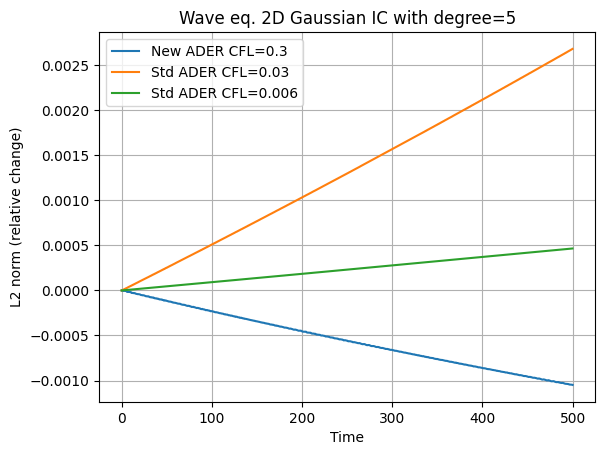

In [19]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    (new_method_norms - new_method_norms[0]) / new_method_norms[0],
    label='New ADER CFL=0.3'
)
plt.plot(
    std_method_unstable_times, 
    (std_method_unstable_norms - std_method_unstable_norms[0]) / std_method_unstable_norms[0],
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    (std_method_stable_norms - std_method_stable_norms[0]) / std_method_stable_norms[0],
    label='Std ADER CFL=0.006'
)
        
plt.ylabel("L2 norm (relative change)")
plt.xlabel("Time")
plt.legend()
plt.grid()

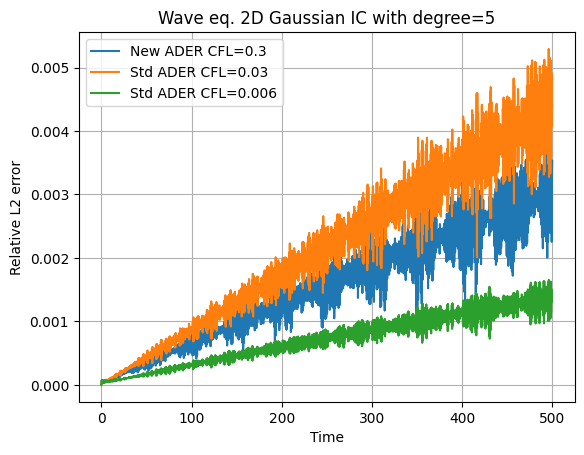

In [20]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    new_method_errors / new_method_norms[0], 
    label='New ADER CFL=0.3'
)
plt.plot(
    std_method_unstable_times, 
    std_method_unstable_errors / std_method_unstable_norms[0], 
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    std_method_stable_errors / std_method_stable_norms[0], 
    label='Std ADER CFL=0.006'
)
plt.ylabel("Relative L2 error")
plt.xlabel("Time")
plt.legend()
plt.grid()

In [23]:
line1 = scipy.stats.linregress(new_method_times, new_method_errors)

In [24]:
line2 = scipy.stats.linregress(std_method_unstable_times, std_method_unstable_errors)

In [40]:
# (line1[0] * scale**6) = line2[0]
scale = (line2[0] / line1[0])**(-1 / 6)
(scale**4) * (1 / 3)

np.float64(0.2596961476021538)

In [32]:
((line1[0] / line2[0])**(4/6))**4

np.float64(0.3684232657308881)

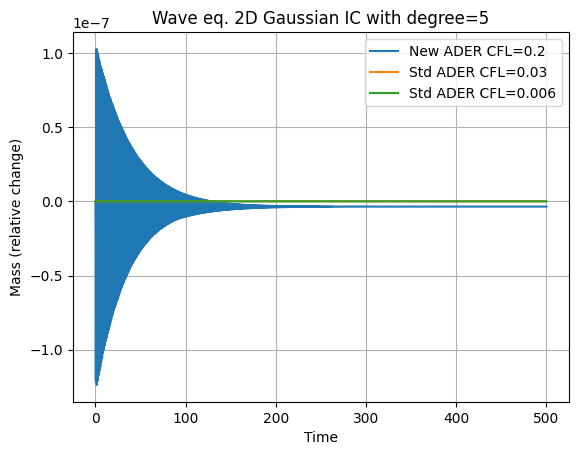

In [75]:
plt.title(f"Wave eq. 2D Gaussian IC with degree={solver.poly_order}")
plt.plot(
    new_method_times, 
    (new_method_masses - new_method_masses[0]) / new_method_masses[0], 
    label='New ADER CFL=0.2'
)
plt.plot(
    std_method_unstable_times, 
    (std_method_unstable_masses - std_method_unstable_masses[0]) / std_method_unstable_masses[0], 
    label='Std ADER CFL=0.03'
)
plt.plot(
    std_method_stable_times, 
    (std_method_stable_masses - std_method_stable_masses[0]) / std_method_stable_masses[0], 
    label='Std ADER CFL=0.006'
)
plt.ylabel("Mass (relative change)")
plt.xlabel("Time")
plt.legend()
plt.grid()

## Snapshots

In [12]:
cfls = {3:0.707, 4:0.44, 5:0.34, 6:0.24219}

In [13]:
tend = 5
o = 5
nx = 20
cfl = cfls[o]
dt = cfl * (xlim / nx)
nsteps = int(tend / dt) + 1
dt = tend / nsteps

h_list = []

solver = WaveAderDG2D(xlim, nx, poly_order=o, c=c, dt=dt)
basis_functions = np.exp(-1.0j * (
    l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
) * 2 * np.pi / solver.xlim)

h0 = analytic_solution(solver, t=0)
solver.h[:] = h0  

h_list.append(np.copy(solver.h))

for _ in range(2):
    for _ in range(nsteps):
        solver.time_step()

    h_list.append(np.copy(solver.h))

Locator attempting to generate 1001 ticks ([0.0, ..., 1.0]), which exceeds Locator.MAXTICKS (1000).


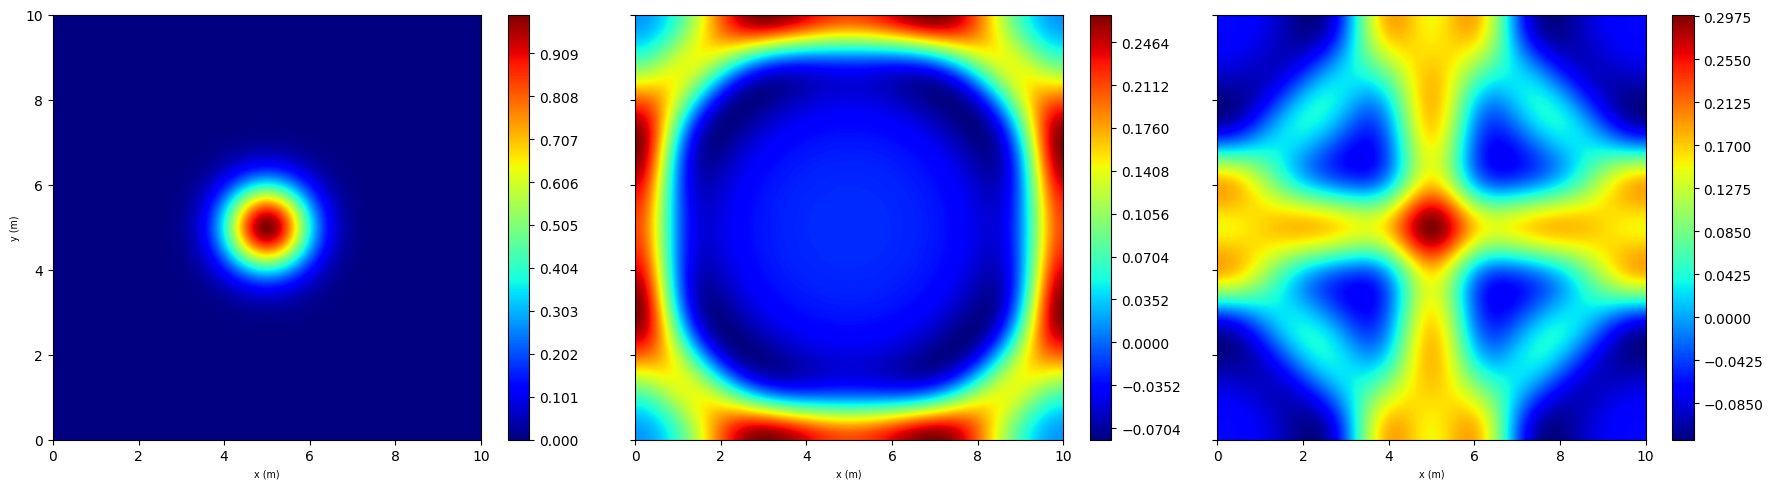

In [21]:
fig, axs = plt.subplots(ncols=3, sharey=True, figsize=(18, 5))

h_min = min(h.min() for h in h_list)
h_max = max(h.max() for h in h_list)
levels = np.linspace(h_min, h_max, 100)

for idx in range(3):
    if idx == 0:
        noise = 1e-12 * np.random.random(h_list[idx].ravel().size)
    else:
        noise = 0
    im = axs[idx].tricontourf(solver.xs[:, :, 0].ravel(), solver.ys[:, :, 0].ravel(), h_list[idx].ravel() + noise, levels=1000, cmap='jet')
    axs[idx].set_xlabel('x (m)', fontsize='x-small')
    plt.colorbar(im, ax=axs[idx])

axs[0].set_ylabel('y (m)', fontsize='x-small')
plt.tight_layout()
plt.savefig('wave-snapshots.png')

## Convergence

In [37]:
tend = 10.0
c = 1.0

In [22]:
%%time
nxs = np.array([5, 7, 10, 12, 15, 20])

orders = [3, 4, 5, 6]

cfls = {3:0.707, 4:0.44, 5:0.34, 6:0.24219}
new_errors = {o:[] for o in orders}
new_mass_errors = {o:[] for o in orders}
new_wall_times = {o:[] for o in orders}

for o in orders:
    for nx in nxs:
    
        cfl = cfls[o]
        dt = cfl * (xlim / nx)
        nsteps = int(tend / dt) + 1
        dt = tend / nsteps
        
        solver = WaveAderDG2D(xlim, nx, poly_order=o, c=c, dt=dt)
        
        basis_functions = np.exp(-1.0j * (
            l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
        ) * 2 * np.pi / solver.xlim)
        
        h0 = analytic_solution(solver, t=0)
        solver.u[:] = 0.0
        solver.v[:] = 0.0
        solver.h[:] = h0
    
        t0 = time.time()
        time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=nsteps - 1)
        t1 = time.time()
        
        new_errors[o].append(error_list[-1])
        new_mass_errors[o].append((mass_list[-1] - mass_list[0]) / mass_list[0])
        new_wall_times[o].append(t1 - t0)
    
    new_errors[o] = np.array(new_errors[o]) 
    new_wall_times[o] = np.array(new_wall_times[o])

CPU times: user 2min 17s, sys: 54.2 s, total: 3min 12s
Wall time: 26.2 s


In [91]:
# nxs = np.array([5, 10, 15, 20])

orders = [3, 4, 5, 6]

cfls = {3:0.084, 4:0.051, 5:0.03320, 6:0.01953}
std_errors = {o:[] for o in orders}
std_mass_errors = {o:[] for o in orders}
std_wall_times = {o:[] for o in orders}

for o in orders:
    for nx in nxs:
    
        # cfl = 0.9 * 0.5 / (2 * poly_order + 1)
        cfl = cfls[o]
        dt = cfl * (xlim / nx)
        nsteps = int(tend / dt) + 1
        dt = tend / nsteps
        
        solver = WaveStandardAderDG2D(xlim, nx, poly_order=o, c=c, dt=dt)
        
        basis_functions = np.exp(-1.0j * (
            l_vals[..., None, None, None, None] * solver.xs[:, :, 0][None] + k_vals[..., None, None, None, None] * solver.ys[:, :, 0][None]
        ) * 2 * np.pi / solver.xlim)
        
        h0 = analytic_solution(solver, t=0)
        solver.u[:] = 0.0
        solver.v[:] = 0.0
        solver.h[:] = h0
        
        t0 = time.time()
        time_list, mass_list, norm_list, error_list = run_solver(solver, nsteps, sample_rate=nsteps - 1)
        t1 = time.time()
        
        std_errors[o].append(error_list[-1])
        std_mass_errors[o].append((mass_list[-1] - mass_list[0]) / mass_list[0])
        std_wall_times[o].append(t1 - t0)
    
    std_errors[o] = np.array(std_errors[o]) 
    std_wall_times[o] = np.array(std_wall_times[o])

dict_keys(['b', 'g', 'r', 'c', 'm', 'y', 'k', 'w'])

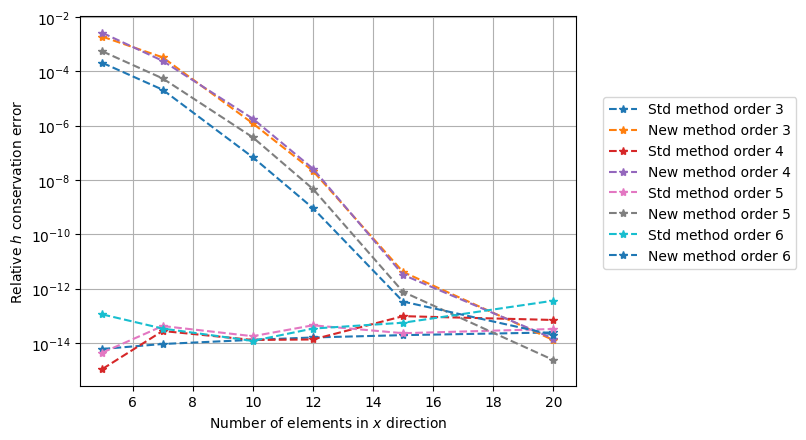

In [123]:
for o, color in zip(orders, list(mcolors.BASE_COLORS.keys())):
    # plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--o', color=color, label=f'Std method order {o}')
    # plt.semilogy(nxs, abs(np.array(new_mass_errors[o])), '--s', color=color, label=f'New method order {o}')

    plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--*', label=f'Std method order {o}')
    plt.semilogy(nxs, abs(np.array(new_mass_errors[o])), '--*', label=f'New method order {o}')
    
    plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--', alpha=0)

# plt.loglog(xlim / nxs, 0.5 * abs(new_mass_errors[orders[-1]][0]) * (nxs[0] / nxs)**(orders[-1]+1), '--', label=f'$\\Delta x^{orders[-1]+1}$')
# plt.legend()
plt.ylabel('Relative $h$ conservation error')
plt.xlabel('Number of elements in $x$ direction')
plt.legend(loc='upper center', bbox_to_anchor=(1.25, 0.8),
          fancybox=True, shadow=False, ncol=1)
plt.grid()
plt.savefig('wave-equation-2D-mass_convergence.png', bbox_inches='tight')

-1.2637437852617135 14.003836396264784
-1.2828536965452342 13.87428993500008
-1.1487110916392493 15.708451137153334
-1.0304944691025693 16.778874004066708


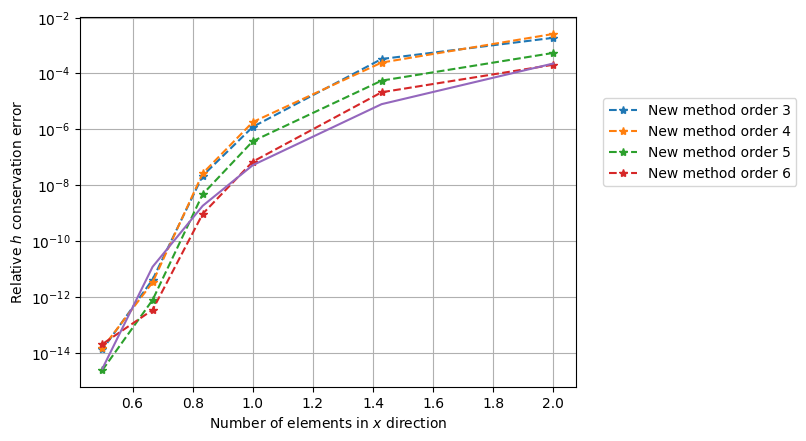

In [182]:
for o, color in zip(orders, list(mcolors.BASE_COLORS.keys())):
    # plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--o', color=color, label=f'Std method order {o}')
    # plt.semilogy(nxs, abs(np.array(new_mass_errors[o])), '--s', color=color, label=f'New method order {o}')

    # plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--*', label=f'Std method order {o}')
    dxs = xlim / nxs
    errors = abs(np.array(new_mass_errors[o]))
    plt.semilogy(dxs, errors, '--*', label=f'New method order {o}')
    slope, intercept, *_ = scipy.stats.linregress(np.log(dxs), np.log(-np.log(errors)))
    print(slope, np.exp(intercept))
    # break
    
    # plt.semilogy(nxs, abs(np.array(std_mass_errors[o])), '--', alpha=0)

k = 1.2
a = 1.2
plt.plot(xlim / nxs, np.exp(-16.77 / dxs))
# plt.loglog(xlim / nxs, 0.5 * abs(new_mass_errors[orders[-1]][0]) * (nxs[0] / nxs)**(orders[-1]+1), '--', label=f'$\\Delta x^{orders[-1]+1}$')
# plt.legend()
plt.ylabel('Relative $h$ conservation error')
plt.xlabel('Number of elements in $x$ direction')
plt.legend(loc='upper center', bbox_to_anchor=(1.25, 0.8),
          fancybox=True, shadow=False, ncol=1)
plt.grid()
# plt.savefig('wave-equation-2D-mass_convergence.png', bbox_inches='tight')

-1.0304944691025693 2.8201205953350024


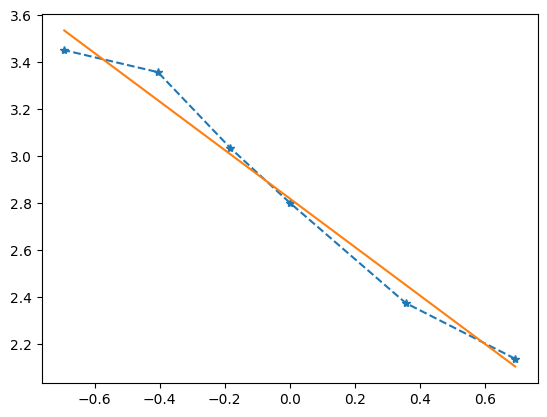

In [169]:
plt.plot(np.log(dxs), np.log(-np.log(errors)), '--*')

plt.plot(np.log(dxs), np.log(dxs) * slope + intercept)

print(slope, intercept)


-1.0304944691025693 16.778874004066708


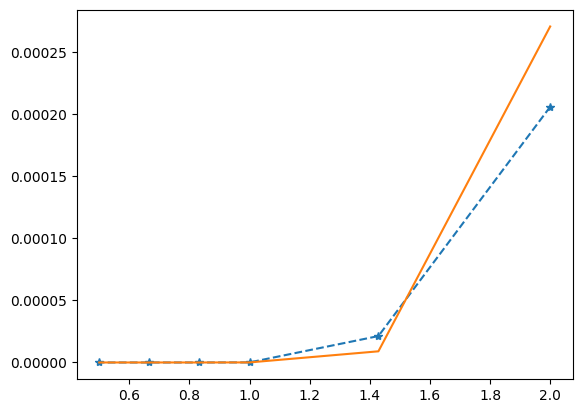

In [177]:
plt.plot(dxs, errors, '--*')

# plt.plot(dxs, np.exp(-np.exp(np.log(dxs) * slope + intercept)))
plt.plot(dxs, np.exp(-np.exp(intercept) * dxs**slope))

print(slope, np.exp(intercept))

In [134]:
nxs

array([ 5,  7, 10, 12, 15, 20])

In [118]:
# for o, color in zip(orders, list(mcolors.BASE_COLORS.keys())):
#     plt.loglog(xlim / nxs, abs(np.array(std_mass_errors[o])), '--o', color=color, label=f'Std method order {o}')
#     plt.loglog(xlim / nxs, abs(np.array(new_mass_errors[o])), '--s', color=color, label=f'New method order {o}')
    
#     plt.loglog(xlim / nxs, 1.5 * abs(new_mass_errors[o][0]) * (nxs[0] / nxs)**o, '-', color=color, label=f'$\\Delta x^{o}$')

# plt.loglog(xlim / nxs, 0.5 * abs(new_mass_errors[orders[-1]][0]) * (nxs[0] / nxs)**(orders[-1]+1), '--', label=f'$\\Delta x^{orders[-1]+1}$')
# # plt.legend()
# plt.ylabel('Relative $h$ conservation error')
# plt.xlabel('Element size $\Delta x$')
# plt.legend(loc='upper center', bbox_to_anchor=(1.25, 0.8),
#           fancybox=True, shadow=False, ncol=1)
# plt.grid()
# plt.savefig('wave-equation-2D-mass_convergence.png', bbox_inches='tight')

<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/w_/6nw19zzn49v8p8ws3d1gm1kdj8tqh5/T/ipykernel_68847/3172556991.py:13: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.xlabel('Element size $\Delta x$')


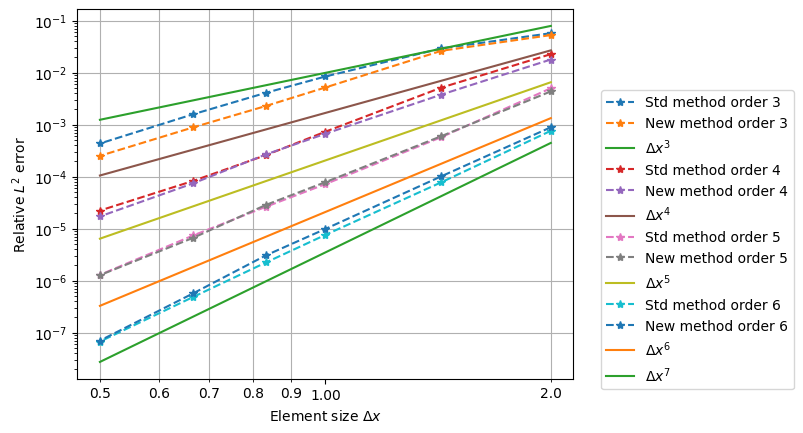

In [158]:
for o, color in zip(orders, list(mcolors.BASE_COLORS.keys())):
    # plt.loglog(xlim / nxs, std_errors[o], '--o', label=f'Std method order {o}', color=color)
    # plt.loglog(xlim / nxs, new_errors[o], '--s', label=f'New method order {o}', color=color)
    # plt.loglog(xlim / nxs, 1.5 * new_errors[o][0] * (nxs[0] / nxs)**o, '-', label=f'$\\Delta x^{o}$', color=color)
    
    plt.loglog(xlim / nxs, std_errors[o], '--*', label=f'Std method order {o}')
    plt.loglog(xlim / nxs, new_errors[o], '--*', label=f'New method order {o}')
    plt.loglog(xlim / nxs, 1.5 * new_errors[o][0] * (nxs[0] / nxs)**o, '-', label=f'$\\Delta x^{o}$')

plt.loglog(xlim / nxs, 0.5 * new_errors[orders[-1]][0] * (nxs[0] / nxs)**(orders[-1]+1), '-', label=f'$\\Delta x^{orders[-1]+1}$')
# plt.legend()
plt.ylabel('Relative $L^2$ error')
plt.xlabel('Element size $\Delta x$')
plt.legend(loc='upper center', bbox_to_anchor=(1.25, 0.8),
          fancybox=True, shadow=False, ncol=1)
plt.grid()
plt.grid(which='both', axis='x')
plt.gca().xaxis.set_major_formatter(mticker.ScalarFormatter())
plt.gca().xaxis.set_minor_formatter(mticker.ScalarFormatter())
plt.savefig('wave-equation-2D-convergence.png', bbox_inches='tight')

In [79]:
print(std_wall_times[3] / new_wall_times[3])
print(std_wall_times[4] / new_wall_times[4])
print(std_wall_times[5] / new_wall_times[5])
print(std_wall_times[6] / new_wall_times[6])

[0.09195152 0.36291581 0.97884468 1.42018223]
[0.18760611 0.74808957 1.39320644 2.23496864]
[0.59985707 1.59880906 2.63380948 2.78883593]
[1.64449414 3.13123237 3.56742174 3.59946281]


<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/var/folders/w_/6nw19zzn49v8p8ws3d1gm1kdj8tqh5/T/ipykernel_97639/1062804164.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Element size $\Delta x$')


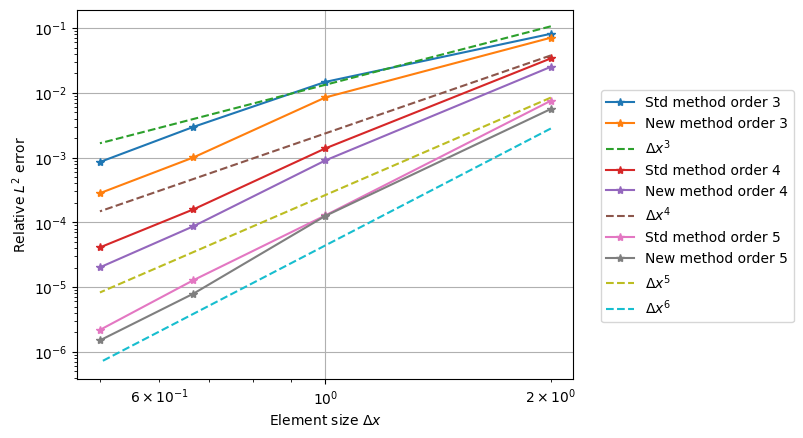

In [75]:
for o in orders:
    plt.loglog(xlim / nxs, std_errors[o], '-*', label=f'Std method order {o}')
    plt.loglog(xlim / nxs, new_errors[o], '-*', label=f'New method order {o}')
    
    plt.loglog(xlim / nxs, 1.5 * new_errors[o][0] * (nxs[0] / nxs)**o, '--', label=f'$\\Delta x^{o}$')

plt.loglog(xlim / nxs, 0.5 * new_errors[orders[-1]][0] * (nxs[0] / nxs)**(orders[-1]+1), '--', label=f'$\\Delta x^{orders[-1]+1}$')
# plt.legend()
plt.ylabel('Relative $L^2$ error')
plt.xlabel('Element size $\Delta x$')
plt.legend(loc='upper center', bbox_to_anchor=(1.25, 0.8),
          fancybox=True, shadow=False, ncol=1)
plt.grid()
plt.savefig('wave-equation-2D-convergence.png', bbox_inches='tight')

In [13]:
print(std_wall_times[3] / new_wall_times[3])
print(std_wall_times[4] / new_wall_times[4])
print(std_wall_times[5] / new_wall_times[5])

[0.09456461 0.30474965 1.29729182 2.61316001]
[0.20989808 1.33786118 1.97697357 2.8008599 ]
[0.75085543 2.0122585  3.03279818 2.38101738]


In [98]:
print(std_wall_times[3] / new_wall_times[3])
print(std_wall_times[4] / new_wall_times[4])
print(std_wall_times[5] / new_wall_times[5])

[0.18645677 0.63791294 1.88547935 3.58119107]
[0.29276624 1.40733557 3.58535602 5.23918472]
[0.87395679 2.8492376  4.37354058 5.12215224]


In [16]:
new_solver = WaveAderDG2D(xlim, nx=20, poly_order=o, c=c, dt=dt)

In [15]:
std_solver = WaveStandardAderDG2D(xlim, nx=20, poly_order=5, c=c, dt=dt)

In [40]:
N = 100

rhs_in = new_solver.get_rhs(new_solver.state)
bdry_integrals = np.copy(rhs_in)

t0 = time.time()
for _ in range(N):
    new_solver._xbdry_nc(bdry_integrals, rhs_in, new_solver.xp_int, new_solver.xm_int)
    new_solver._ybdry_nc(bdry_integrals, rhs_in, new_solver.yp_int, new_solver.ym_int)
    new_solver._xbdry_nc(bdry_integrals, rhs_in, new_solver.xp_ext, new_solver.xm_ext)
    new_solver._ybdry_nc(bdry_integrals, rhs_in, new_solver.yp_ext, new_solver.ym_ext)

t1 = time.time()

print((t1 - t0) / N)

0.0011736607551574706


In [59]:
N = 1000

rhs_in = new_solver.get_rhs(new_solver.state)
bdry_integrals = np.copy(rhs_in)

t0 = time.time()
for _ in range(N):
    rhs = bdry_integrals.reshape(new_solver.nx * new_solver.ny, -1).transpose()
    state_out = lu_solve(new_solver.M_nc_lu, rhs).transpose().copy().reshape(bdry_integrals.shape)

t1 = time.time()

print((t1 - t0) / N)

0.004873376131057739


In [60]:
N = 1000

rhs_in = new_solver.get_rhs(new_solver.state)
bdry_integrals = np.copy(rhs_in)

t0 = time.time()
for _ in range(N):
    _ = new_solver.preconditioner(rhs_in)

t1 = time.time()

print((t1 - t0) / N)

0.00451041316986084


In [57]:
N = 1000
t0 = time.time()
for _ in range(N):
    _ = new_solver.time_step()

t1 = time.time()

print((t1 - t0) / N)

0.024160557270050047


In [58]:
N = 1000
t0 = time.time()
for _ in range(N):
    _ = std_solver.time_step()

t1 = time.time()

print((t1 - t0) / N)

0.006815477848052979


In [33]:
N = 100

rhs_in = new_solver.get_rhs(new_solver.state)
bdry_integrals = np.copy(rhs_in)

t0 = time.time()
for _ in range(N):
    

t1 = time.time()

print((t1 - t0) / N)

0.0002331376075744629
